In [ ]:
pip install wordcloud

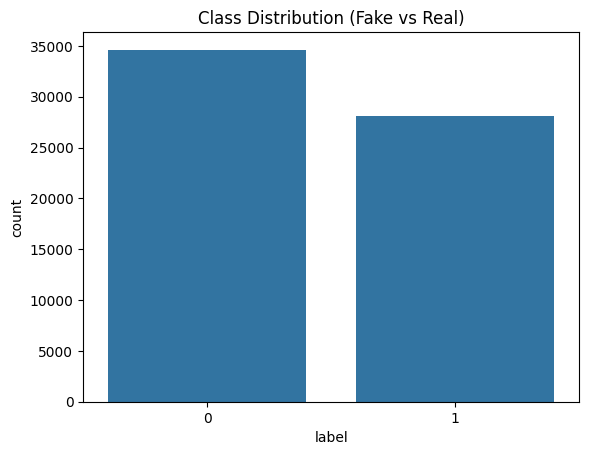

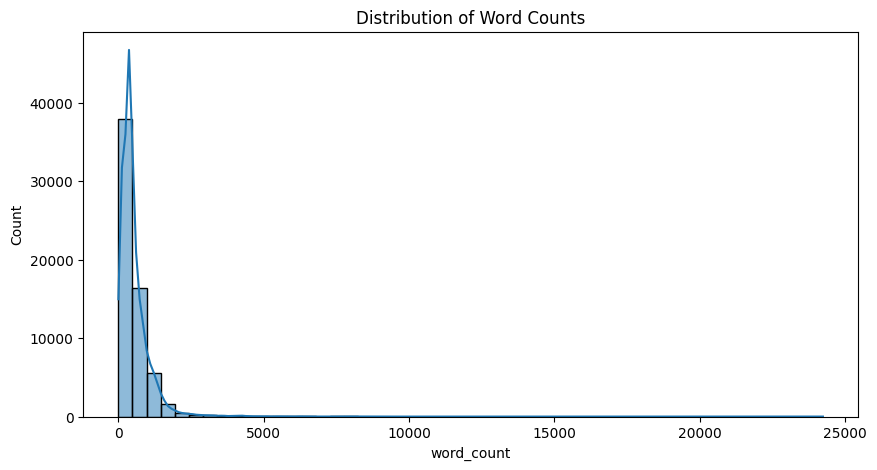

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import nltk
from nltk.corpus import stopwords
import re

# Load data
df = pd.read_pickle("../../data/processed/welfake_cleaned.pkl")

# 1. Class distribution
sns.countplot(x=df['label'])
plt.title("Class Distribution (Fake vs Real)")
plt.show()

# 2. Text length distribution
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['text'].apply(lambda x: len(str(x)))

plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=50, kde=True)
plt.title("Distribution of Word Counts")
plt.show()

# 3. WordCloud for Fake news
real_text = " ".join(df[df['label']==1]['text'])
fake_text = " ".join(df[df['label']==0]['text'])

wc_fake = WordCloud(stopwords=set(stopwords.words('english')), background_color="black").generate(fake_text)
wc_real = WordCloud(stopwords=set(stopwords.words('english')), background_color="white").generate(real_text)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(wc_fake, interpolation="bilinear")
plt.title("Fake News WordCloud")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(wc_real, interpolation="bilinear")
plt.title("Real News WordCloud")
plt.axis("off")

plt.show()
